In [ ]:
#Creating Molecular Images for My Master's Thesis

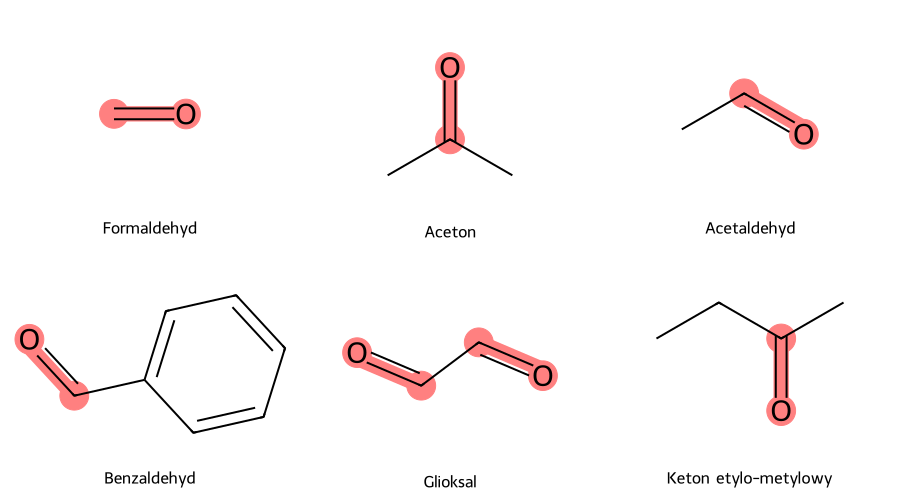

In [17]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage
from IPython.display import display

molecules = [
    ("Formaldehyd", "C(=O)"),
    ("Aceton", "CC(=O)C"),
    ("Acetaldehyd", "CC=O"),
    ("Benzaldehyd", "O=Cc1ccccc1"),
    ("Glioksal", "O=CC=O"),
    ("Keton etylo-metylowy", "CCC(=O)C")
]

carbonyl = Chem.MolFromSmarts("[CX3]=[OX1]")

mols = []
highlight_atoms = []
highlight_bonds = []

for name, smiles in molecules:
    mol = Chem.MolFromSmiles(smiles)
    mols.append(mol)

    matches = mol.GetSubstructMatches(carbonyl)

    atoms = []
    bonds = []

    for carbon_atom, oxygen_atom in matches:
        atoms.extend([carbon_atom, oxygen_atom])

        bond = mol.GetBondBetweenAtoms(carbon_atom, oxygen_atom)
        bonds.append(bond.GetIdx())

    highlight_atoms.append(atoms)
    highlight_bonds.append(bonds)

img = MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 250),
    legends=[name for name, smiles in molecules],
    highlightAtomLists=highlight_atoms,
    highlightBondLists=highlight_bonds
)

display(img)

In [18]:
img.data
with open("zwiazki_karbonylowe.png", "wb") as f:
    f.write(img.data)